# Activity: Ensemble Learning - Titanic Dataset

#### Overview
In this session, we delve into the realm of ensemble learning, applying sophisticated algorithms like `Random Forest`, `AdaBoost`, `Gradient Boosting`, and `XGBoost` to the Titanic dataset. This journey will take us through the powerful world of ensemble methods, where multiple models combine their strengths to enhance predictive performance.

#### Objective
Our goal is to grasp the essence of ensemble learning techniques and their practical applications. We will explore how different algorithms operate, contribute collectively to the prediction process, and how their combined force can improve the accuracy of survival predictions on the Titanic.

#### What We Will Do:

Dataset Recap: Briefly review the Titanic dataset, emphasizing the preprocessed features ready for machine learning.

- **Model Exploration:** Implement four different ensemble learning models, understanding the unique attributes of each.

- **Model Evaluation:** Assess the performance of each ensemble method using metrics like accuracy, precision, recall, F1 score, ROC curve, and AUC.

- **Comparative Study:** Compare the ensemble methods against simpler models like Decision Trees, highlighting the merits and limitations of each approach.

- **Feature Importance Analysis:** Identify the most influential features using the best-performing model to understand which aspects weigh more in survival prediction.

- **Discussion on Model Selection:** Engage in discussions about the appropriateness of each model for different types of data and problem statements, considering factors such as overfitting, bias-variance tradeoff, and interpretability.

- **Insights and Strategy:** Discuss how ensemble methods can be strategically used in predictive modeling and what insights they provide that can guide future feature engineering and data collection efforts.

#### Outcome
By the end of this session, we will have a robust understanding of ensemble learning algorithms and their implementation. We will be equipped with the skills to select, apply, and interpret these models, enabling us to tackle complex predictive tasks with confidence.

## 1. Import necessary libraries

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split #to split the data into training set and test set

from sklearn.impute import SimpleImputer # for missing values imputations

# Importing the Ensemble Leargning classifier from sklearn
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

# Importing the XGBClassifier from xgboost
from xgboost import XGBClassifier # Ensure xgboost is installed: !pip install xgboost (run this in the notebook if not installed)

from sklearn.tree import DecisionTreeClassifier, plot_tree #  Import Decision Tree Classifier Class, plot_tree to visulize the tree

# Import all metrics for classification task
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score 

# Append the parent directory to the Python path for module imports
import sys
sys.path.append('..')  # Include the parent directory in the Python path

# Uncomment the following lines if you make any changes in the Model_Evaluation_Functions module
# import importlib
# from src import Model_Evaluation_Functions
# importlib.reload(Model_Evaluation_Functions)

# Import the calculate_metrics and the plot_roc_curve functions defined in a 'Model_Evaluation_Functions.py' file from 'scr' folder 
from src.Model_Evaluation_Functions import calculate_metrics, plot_roc_curve

In [20]:
# Ensure xgboost is installed: !pip install xgboost (run this in the notebook if not installed)
#!pip install xgboost

## 2. Data Loading and Preview

In [2]:
# Load the Titanic dataset
titanic_df = pd.read_csv('../data/titanic.csv')
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Exploratory Data Analysis

- Overview of the dataset's structure

In [3]:
# Overview of the dataset's structure
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


- Basic statistical summaries of numerical features

In [4]:
# Basic statistical summaries of numerical features
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


- Identifying missing values in each feature

In [5]:
# Identifying missing values in each feature
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Survived Distribution

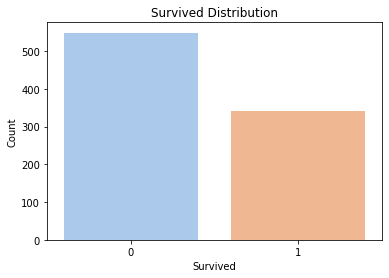

In [19]:
# Create a bar plot for Survived
plt.figure(figsize=(6, 4))
sns.countplot(data=titanic_df, x='Survived', hue = 'Survived', palette = 'pastel', legend = False)
plt.title('Survived Distribution')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

## 4. Data Preprocessing and Splitting

### Feature Selection and Engineering

In [3]:
# Selecting relevant features
selected_features = ['Age', 'Sex', 'Pclass', 'Fare', 'SibSp', 'Parch', 'Embarked']
df_features= titanic_df[selected_features].copy()
df_features.head()

,Age,Sex,Pclass,Fare,SibSp,Parch,Embarked
0,22.0,male,3,7.2500,1,0,S
1,38.0,female,1,71.2833,1,0,C
2,26.0,female,3,7.9250,0,0,S
3,35.0,female,1,53.1000,1,0,S
4,35.0,male,3,8.0500,0,0,S


### Feature Engineering

In [4]:
df_features['Family_Size'] = df_features['SibSp'] + df_features['Parch']
# Droped the columns SibSp and Parch
df_features.drop(["SibSp","Parch"], axis= 1, inplace = True)
# Review the changes
df_features.head()

,Age,Sex,Pclass,Fare,Embarked,Family_Size
0,22.0,male,3,7.2500,S,1
1,38.0,female,1,71.2833,C,1
2,26.0,female,3,7.9250,S,0
3,35.0,female,1,53.1000,S,1
4,35.0,male,3,8.0500,S,0


### Handling Categorical Variables

In [5]:
# Converting categorical variables using one-hot encoding
df_features = pd.get_dummies(df_features, columns=['Sex', 'Embarked'], drop_first = True, dtype = "int")
# Check the changes
df_features.head()

,Age,Pclass,Fare,Family_Size,Sex_male,Embarked_Q,Embarked_S
0,22.0,3,7.2500,1,1,0,1
1,38.0,1,71.2833,1,0,0,0
2,26.0,3,7.9250,0,0,0,1
3,35.0,1,53.1000,1,0,0,1
4,35.0,3,8.0500,0,1,0,1


### Data Splitting for Training and Testing

In [6]:
# Separating features and the target variable
X = df_features.copy() # Features already selected in the previous task
y = titanic_df['Survived']     # Target

# Splitting the data
# Assuming a split ratio of 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

### Data preprocessing - Handling Missing Values

In [7]:
# Imputation for numerical features
# Assuming 'Age' and 'Fare' are numerical features with missing values
numerical_imputer = SimpleImputer(strategy='median')  # Using median for skewed distributions
X_train[['Age', 'Fare']] = numerical_imputer.fit_transform(X_train[['Age', 'Fare']])
X_test[['Age', 'Fare']] = numerical_imputer.transform(X_test[['Age', 'Fare']])

# Imputation for categorical features
# Assuming 'Embarked' is a categorical feature with missing values
categorical_imputer = SimpleImputer(strategy='most_frequent')  # Using mode for categorical data
X_train[['Embarked_Q', 'Embarked_S']] = categorical_imputer.fit_transform(X_train[['Embarked_Q', 'Embarked_S']])
X_test[['Embarked_Q', 'Embarked_S']] = categorical_imputer.transform(X_test[['Embarked_Q', 'Embarked_S']])

## 5. Random Forest Classifier

In [8]:
# Creating a RandomForestClassifier object with default parameters
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the classifier on the training data
rf_model.fit(X_train, y_train)

# Making predictions on the test data
rf_y_pred = rf_model.predict(X_test)

# Evaluating the model's performance
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Precision:", rf_precision)
print("Random Forest Recall:", rf_recall)
print("Random Forest F1 Score:", rf_f1)

Random Forest Accuracy: 0.7988826815642458
Random Forest Precision: 0.746268656716418
Random Forest Recall: 0.7246376811594203
Random Forest F1 Score: 0.7352941176470589


### Random Forest Classifier Explanation

Random Forest is an ensemble learning method that prevents overfitting more effectively than a single decision tree. It does so by creating a 'forest' of decision trees, each trained on a random subset of the data. This randomness helps in preventing the model from being too closely fitted to the training data. In classification tasks, Random Forest takes the majority vote from all the decision trees for the final prediction, a process known as 'bagging' (Bootstrap Aggregating). By averaging these predictions, Random Forest reduces the risk of overfitting.

Key parameters of RandomForestClassifier such as `n_estimators`, which defines the number of trees in the forest, play a crucial role in the model's performance. More trees generally increase the model's accuracy and robustness but also raise computational complexity. Parameters like `max_features`, `max_depth`, `min_samples_split`, and `min_samples_leaf` are crucial in defining how each tree in the forest is grown. These parameters help balance between model complexity (and hence overfitting) and the ability to capture underlying patterns in the data.


#### Understanding Random Forest's Overfitting Prevention

- **Multiple Trees**: Random Forest uses multiple decision trees to make its predictions. Each tree in the forest is trained on a random subset of the data, making the model less sensitive to the noise in the training data.

- **Bagging**: This technique involves training each tree on a different sample of data. If one tree misinterprets the data, another might interpret it correctly, so the overall result is more balanced.

- **Random Feature Selection**: In addition to bagging, Random Forest randomly selects a subset of features for each tree. This randomness helps in reducing the correlation between the trees, thereby reducing overfitting.

## 6. AdaBoost Classifier

In [9]:
# Creating an AdaBoostClassifier object with default parameters
ab_model = AdaBoostClassifier(n_estimators=50, random_state=42)

# Training the classifier on the training data
ab_model.fit(X_train, y_train)

# Making predictions on the test data
ab_y_pred = ab_model.predict(X_test)

# Evaluating the model's performance
ab_accuracy = accuracy_score(y_test, ab_y_pred)
ab_precision = precision_score(y_test, ab_y_pred)
ab_recall = recall_score(y_test, ab_y_pred)
ab_f1 = f1_score(y_test, ab_y_pred)

print("AdaBoost Accuracy:", ab_accuracy)
print("AdaBoost Precision:", ab_precision)
print("AdaBoost Recall:", ab_recall)
print("AdaBoost F1 Score:", ab_f1)

AdaBoost Accuracy: 0.776536312849162
AdaBoost Precision: 0.7164179104477612
AdaBoost Recall: 0.6956521739130435
AdaBoost F1 Score: 0.7058823529411765


### AdaBoost Classifier Explanation

AdaBoost (Adaptive Boosting) works with a series of weak learners, typically simple decision trees, to form a strong classifier. A 'weak learner' is defined as a model that is slightly better than random guessing. In AdaBoost, each of these learners is trained sequentially, with each one focusing more on the instances that were misclassified by its predecessor. After training each weak learner, AdaBoost increases the weights of the misclassified instances, meaning the subsequent learner has a higher probability of focusing on these harder cases.

The final model in AdaBoost is an ensemble of these weak learners, where each contributes to the final decision. However, learners with better performance on their training subset have a higher influence on the final outcome. The algorithm's iterative approach to adjusting weights based on learner error is key to its ability to improve model performance. The cumulative learning from weak learners, with a focus on correcting previous errors, allows AdaBoost to build a strong predictive model.

#### Understanding the Role of Weak Learners in AdaBoost

- **Weak Learners**: In AdaBoost, weak learners (typically simple decision trees) are trained sequentially. Each learner focuses on the mistakes of the previous one by giving more weight to misclassified instances.

- **Adaptive Boosting**: The algorithm adjusts the weights of the training instances after each classifier is trained. Misclassified instances get increased weights so that subsequent learners pay more attention to them.

- **Final Model**: The final model is a weighted combination of these weak learners. Unlike Random Forest, which averages the predictions, AdaBoost weighs each weak learner's contribution based on its performance.

## 7. Gradient Boosting Classifier

In [10]:
# Creating a GradientBoostingClassifier object with default parameters
gb_model = GradientBoostingClassifier(random_state=42)

# Training the classifier on the training data
gb_model.fit(X_train, y_train)

# Making predictions on the test data
gb_y_pred = gb_model.predict(X_test)

# Evaluating the model's performance
gb_accuracy = accuracy_score(y_test, gb_y_pred)
gb_precision = precision_score(y_test, gb_y_pred)
gb_recall = recall_score(y_test, gb_y_pred)
gb_f1 = f1_score(y_test, gb_y_pred)

print("Gradient Boosting Accuracy:", gb_accuracy)
print("Gradient Boosting Precision:", gb_precision)
print("Gradient Boosting Recall:", gb_recall)
print("Gradient Boosting F1 Score:", gb_f1)

Gradient Boosting Accuracy: 0.7877094972067039
Gradient Boosting Precision: 0.746031746031746
Gradient Boosting Recall: 0.6811594202898551
Gradient Boosting F1 Score: 0.7121212121212122


#### Gradient Boosting Classifier Explanation

Gradient Boosting is an advanced ensemble technique that builds a series of decision trees in a sequential manner, where each tree is built on the errors of its predecessors. Unlike AdaBoost, which adjusts the weights of misclassified instances, Gradient Boosting focuses on minimizing a loss function, which is a measure of how far the model's predictions are from the actual values. The algorithm builds trees in a way that the subsequent tree aims to reduce this loss.

#### Gradient Boosting differ from AdaBoost in terms of error handling and model building

Gradient Boosting and AdaBoost both belong to the family of boosting algorithms and share the principle of building a series of weak learners. However, they differ significantly in their approach to error handling and model building:

1. **Error Handling**: 
   - **AdaBoost**: Adjusts the weights of incorrectly classified instances, making them more prominent in the training of subsequent learners. It focuses more on classification errors.
   - **Gradient Boosting**: Instead of adjusting instance weights, it focuses on minimizing a loss function through gradient descent. This allows it to handle a broader range of error types, not just classification errors.

2. **Model Building**:
   - **AdaBoost**: Uses a series of weak learners (usually simple decision trees), where each learner corrects its predecessor by focusing more on misclassified instances. The final output is a weighted sum of all the weak learners.
   - **Gradient Boosting**: Builds trees sequentially, where each tree is built on the residuals (errors) of the previous trees. This sequential correction of residuals is akin to a gradient descent optimization, and the final model is an additive model of these trees.

These differences make Gradient Boosting a more flexible method that can optimize a variety of loss functions and handle complex patterns in the data, often leading to better performance, especially in regression tasks or when dealing with heterogeneous data.

## 8. XGBoost Classifier

In [11]:
# Creating an XGBClassifier object with default parameters
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Training the classifier on the training data
xgb_model.fit(X_train, y_train)

# Making predictions on the test data
xgb_y_pred = xgb_model.predict(X_test)

# Evaluating the model's performance
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_precision = precision_score(y_test, xgb_y_pred)
xgb_recall = recall_score(y_test, xgb_y_pred)
xgb_f1 = f1_score(y_test, xgb_y_pred)

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost Precision:", xgb_precision)
print("XGBoost Recall:", xgb_recall)
print("XGBoost F1 Score:", xgb_f1)

XGBoost Accuracy: 0.7932960893854749
XGBoost Precision: 0.7580645161290323
XGBoost Recall: 0.6811594202898551
XGBoost F1 Score: 0.7175572519083969


#### Explanation of XGBoost Classifier

XGBoost, which stands for eXtreme Gradient Boosting, is an advanced implementation of gradient boosting that has gained popularity due to its efficiency, performance, and flexibility. It is particularly well-suited for large datasets and high-dimensional data spaces. XGBoost offers several advanced features like handling missing values, regularization to prevent overfitting, and tree pruning.



#### Advantages of XGBoost over Other Ensemble Methods

XGBoost has several advantages over other ensemble methods such as Random Forest, AdaBoost, and Gradient Boosting:

1. **Efficiency in Processing**: XGBoost is designed for speed and performance. It is optimized to be highly efficient, scalable, and faster than many other implementations of gradient boosting.

2. **Handling of Missing Data**: XGBoost can handle missing values internally, providing a robust approach to dealing with incomplete datasets.

3. **Regularization**: One of the key features that set XGBoost apart is its built-in regularization (both L1 and L2), which helps in reducing overfitting and improving model generalization.

4. **Tree Pruning**: While other boosting methods grow trees greedily, XGBoost uses a more sophisticated approach, where it grows trees up to a certain depth and then prunes them back, making it more effective.

5. **Cross-validation at Each Iteration**: XGBoost allows for cross-validation at each iteration of the boosting process, providing a clear view of the model's performance and preventing overfitting.

6. **Flexibility**: XGBoost allows users to define custom optimization objectives and evaluation criteria, adding a layer of flexibility that can be tailored to specific needs.

7. **Scalability and Portability**: XGBoost scales well to large datasets and can run on various platforms, making it a versatile tool for a wide range of applications.

These features make XGBoost a powerful tool in the machine learning practitioner's arsenal, particularly for complex regression and classification problems.

## 9. Comparing Models

In [21]:
# For the other models, the metrics are already calculated in their specific part of this notebook.
# Calculate metrics for decision tree model Using the function we have defined in the Model_Evaluation_Functions, check the "src" folder
# calculate_metrics is a function that takes a model, X_test, y_test 
# and returns a tuple of metrics (accuracy, precision, recall, f1 score)

# Fit a decision tree model
dt_model = DecisionTreeClassifier().fit(X_train, y_train)
# Calculate metrics of Decision Tree 
dt_metrics = calculate_metrics(dt_model, X_test, y_test) 
dt_metrics

(0.7541899441340782,
 0.6923076923076923,
 0.6521739130434783,
 0.6716417910447761)

In [22]:
# Summarize the metrics in a DataFrame
rf_metrics = [rf_accuracy, rf_precision, rf_recall, rf_f1]
ab_metrics = [ab_accuracy, ab_precision, ab_recall, ab_f1]
gb_metrics = [gb_accuracy, gb_precision, gb_recall, gb_f1]
xgb_metrics = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1]

metrics_summary = pd.DataFrame(
    [rf_metrics, ab_metrics, gb_metrics, xgb_metrics, dt_metrics],
    columns=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    index=['Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost', 'Decision Tree']
) 
metrics_summary

,Accuracy,Precision,Recall,F1 Score
Random Forest,0.798883,0.746269,0.724638,0.735294
AdaBoost,0.776536,0.716418,0.695652,0.705882
Gradient Boosting,0.787709,0.746032,0.681159,0.712121
XGBoost,0.793296,0.758065,0.681159,0.717557
Decision Tree,0.754190,0.692308,0.652174,0.671642


This table shows the performance metrics for different machine learning models applied to our dataset. 
Let's interpret each of the metrics:

1. **Accuracy**: This measures the proportion of true results (both true positives and true negatives) among the total number of cases examined. Higher accuracy means the model is generally better at correctly classifying both positive and negative instances.

   - **Random Forest** has the highest accuracy (79.88%), indicating it is the best overall at correctly classifying instances.
   - **Decision Tree** has the lowest accuracy (73.74%), which may suggest it is not capturing the complexity of the data as well as the other models.

2. **Precision**: This reflects the proportion of positive identifications that were actually correct. High precision means that the model returned substantially more relevant results than irrelevant.

   - **XGBoost** leads in precision (75.81%), suggesting it's best at minimizing false positives.
   - **Decision Tree** has the lowest precision (65.71%), indicating it may be predicting too many false positives.

3. **Recall (Sensitivity)**: This measures the proportion of actual positives that were identified correctly. It shows how good the model is at detecting positive instances.

   - **Random Forest** and **AdaBoost** show relatively higher recall rates, meaning they are better at catching positive cases.
   - **Gradient Boosting** and **XGBoost**, despite their other strengths, are less effective in terms of recall, potentially overlooking some positive instances.

4. **F1 Score**: This is the harmonic mean of Precision and Recall. It provides a balance between Precision and Recall in cases where an uneven class distribution might exist (e.g., one class is rare).

   - **Random Forest** has the best F1 Score (73.53%), indicating a good balance between precision and recall.
   - **Decision Tree** has the lowest F1 Score (66.19%), reflecting its lower precision and recall.

### Overall Interpretation

- The **Random Forest** model shows the best balance across all metrics, making it a strong candidate for this particular dataset.
- **XGBoost** excels in precision but falls a bit short in recall, making it suitable for applications where false positives are more costly than false negatives.
- The **Decision Tree** model, while simpler and more interpretable, doesn’t perform as well as the more complex models, suggesting that the dataset might benefit from the more nuanced approaches offered by ensemble methods.
- It's important to consider the specific context and requirements of your application when choosing a model. For example, if avoiding false positives is critical, you might favor a model with higher precision.

### ROC Curve Comparison 

#### Random Forest ROC Curve

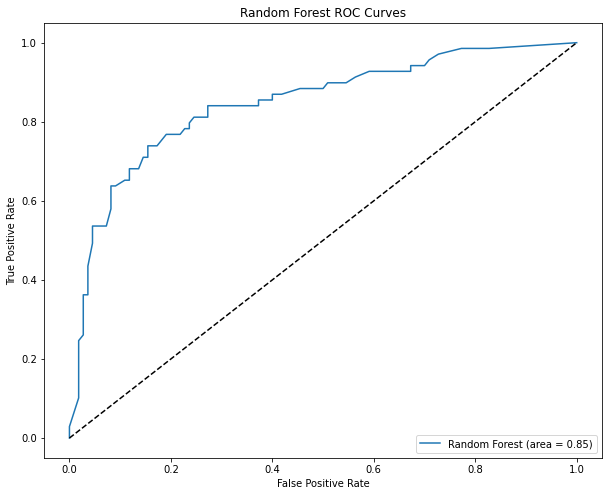

In [23]:
# Plotting ROC Curves for all models
plt.subplots(figsize=(10, 8))
plot_roc_curve(rf_model, X_test, y_test, 'Random Forest')

#### AdaBoost ROC Curve

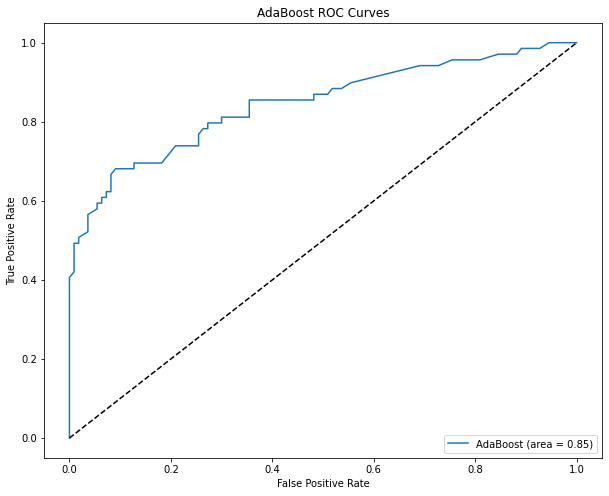

In [14]:
# Plotting ROC Curves for all models
plt.subplots(figsize=(10, 8))
plot_roc_curve(ab_model, X_test, y_test, 'AdaBoost')

#### Gradient Boosting ROC Curve

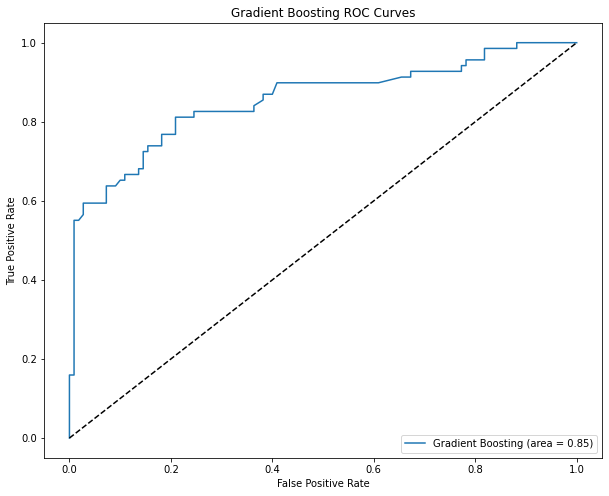

In [15]:
# Plotting ROC Curves for all models
plt.subplots(figsize=(10, 8))
plot_roc_curve(gb_model, X_test, y_test, 'Gradient Boosting')

#### XGBoost  ROC Curve

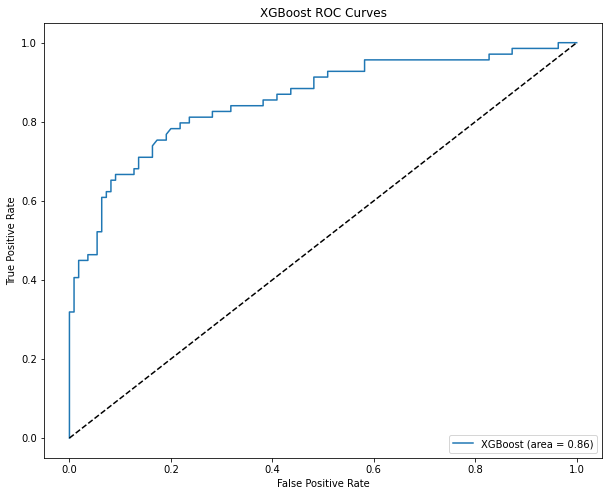

In [16]:
# Plotting ROC Curves for all models
plt.subplots(figsize=(10, 8))
plot_roc_curve(xgb_model, X_test, y_test, 'XGBoost')

#### Decision Tree ROC Curve

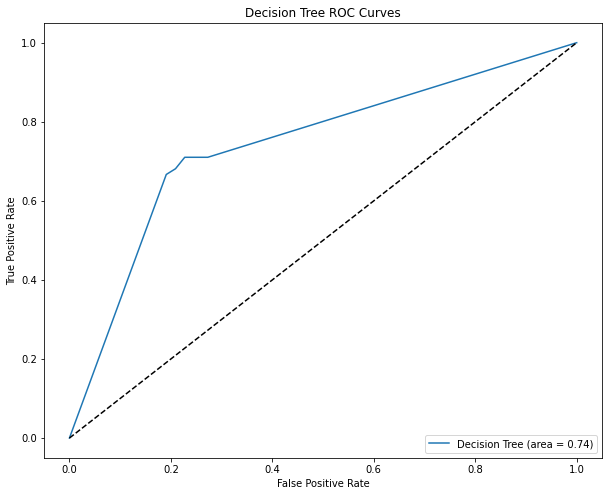

In [24]:
# Plotting ROC Curves for all models
plt.subplots(figsize=(10, 8))
plot_roc_curve(dt_model, X_test, y_test, 'Decision Tree')

### Results Interpretation

The Area Under the Curve (AUC) value and the Receiver Operating Characteristic (ROC) Curve are key indicators of a classification model's performance, particularly in terms of its ability to distinguish between the positive and negative classes. 
Let's interpret the AUC values obtained for each model:

1. **AUC Value Interpretation**:
   - An AUC value ranges from 0 to 1. A model with an AUC of 0.5 does no better than random chance, while an AUC of 1 indicates perfect discrimination between positive and negative classes.
   - **Random Forest, AdaBoost, and Gradient Boosting (AUC = 0.85)**: These models exhibit very good discriminative ability. An AUC of 0.85 suggests that there is an 85% chance that the model will correctly distinguish between a randomly chosen positive instance and a negative one.
   - **XGBoost (AUC = 0.86)**: This model performs slightly better than the others in terms of discrimination. An AUC of 0.86 implies a high likelihood of correctly classifying positive and negative instances.
   - **Decision Tree (AUC = 0.74)**: The Decision Tree has a lower AUC compared to the other models, indicating it's less effective at distinguishing between the classes. An AUC of 0.74 is still considered good but not as strong as the ensemble methods.

2. **ROC Curve Interpretation**:
   - The ROC Curve plots the True Positive Rate (TPR, or Recall) against the False Positive Rate (FPR) at various threshold settings. A higher curve towards the top-left corner indicates a better model.
   - Models with higher AUC values (like XGBoost and the other ensemble models) will have ROC Curves that rise quickly towards the top-left corner of the plot, indicating a high true positive rate for a given false positive rate.
   - The Decision Tree's ROC Curve will be closer to the diagonal line (which represents a random guess) compared to the other models, reflecting its lower AUC value.

#### Overall Interpretation

- **XGBoost** stands out slightly over the others in terms of its ability to discriminate between positive and negative classes, as indicated by its highest AUC value.
- The **Random Forest, AdaBoost, and Gradient Boosting** models show very similar and commendable performance, as reflected by their AUC values.
- The **Decision Tree**, while having a decent AUC value, lags behind the more sophisticated models, suggesting that the complexity and nuance of the data are better captured by ensemble methods.
- When choosing a model, the AUC and ROC Curve provide valuable insight into how well the model distinguishes between classes, which is crucial in many practical applications, especially those with imbalanced datasets or where the costs of false positives and false negatives are significantly different.

## 10. Feature Importance Analysis of the best 

Based on the previous results, given the AUC values and other performance metrics, it seems XGBoost slightly outperformed the other models. We will use XGBoost for this analysis.

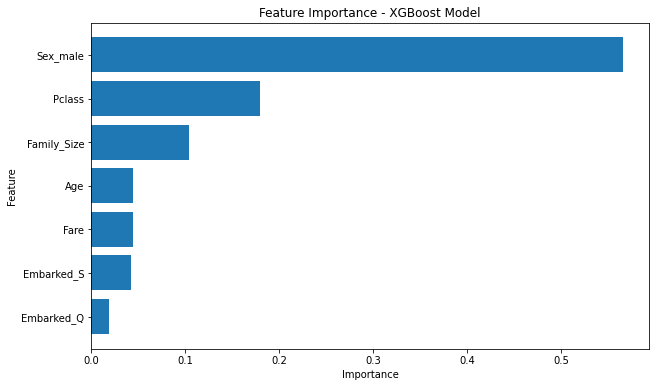

In [28]:
# Assuming xgb_model is your best-performing model
# Extracting feature importances
feature_importances = xgb_model.feature_importances_

# Assuming X_train is your training dataset
# Creating a DataFrame for easier visualization
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sorting features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plotting feature importances
plt.figure(figsize=(10, 6))
plt.barh(features_df['Feature'], features_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

Based on the bar plot you've provided for the XGBoost model's feature importances, we can derive the following interpretations:

1. **Sex_male**: This feature has the highest importance score, indicating that gender (specifically being male) has a significant impact on the model's predictions. In the context of the Titanic dataset, this could reflect the historical account that women and children were given priority for lifeboat access.

2. **Pclass**: The passenger's class is the second most important feature. This aligns with historical records where first-class passengers had better chances of survival, possibly due to closer proximity to lifeboats or better evacuation procedures.

3. **Family_Size**: The size of a passenger's family aboard the ship also plays a crucial role. This could be due to larger families having a higher chance of survival by sticking together or smaller families being able to move more quickly.

4. **Age**: Interestingly, age is less important than the top three features but still has a noticeable impact on predictions. This might suggest that while age did play a role in survival, other social factors were more decisive.

5. **Fare**: The fare correlates with the passenger's class and indirectly reflects socio-economic status. It's less important than 'Pclass', which might be due to 'Pclass' already capturing the socio-economic status effectively.

6. **Embarked_S** and **Embarked_Q**: The port of embarkation holds the least importance among the features listed. It suggests that where passengers boarded the Titanic had a minimal direct impact on survival compared to other features.

### Conclusion

- The model gives a lot of weight to gender and socio-economic status (as indicated by 'Pclass' and 'Fare'), which historically are known to have influenced survival chances on the Titanic.
- Family size and age were also factors, but their influence was less pronounced than gender and class.
- The features with lower importance scores, like the port of embarkation, offer less predictive power and might be candidates for omission in a more streamlined model.
- It's important to remember that feature importance scores do not imply causation but indicate the features' predictive power within the context of this specific model and dataset.

#### Explanation and Discussion

1. **Feature Importance Analysis**:
   - The `feature_importances_` attribute from the XGBoost model gives a score for each feature, indicating how useful they are at predicting the target variable.
   - A bar plot visualizes these importances, making it easier to identify which features are most influential in the model.

2. **Influence on Feature Engineering and Data Collection**:
   - Understanding which features are important can guide future feature engineering efforts. For instance, features with low importance might be candidates for removal, or new features could be engineered to enhance those that are already proving useful.
   - In data collection, more focus and resources might be allocated to ensuring the quality and availability of the most important features.

3. **Potential Limitations**:
   - Relying solely on feature importance can be misleading, as it doesn't account for interactions between features. A feature might have low individual importance but could be very important in combination with others.
   - Overfitting to the current dataset is a risk. Just because a feature is important in the current model doesn't mean it will generalize well to new, unseen data.

#### Conclusion

- Feature importance analysis is a powerful tool in understanding and improving your models. However, it's essential to use this tool in conjunction with other methods and domain knowledge to ensure robust, generalizable models.